100%|██████████| 9.91M/9.91M [00:01<00:00, 5.80MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.84MB/s]


Epoch 1/3 | Generator Loss: 0.5920 | Discriminator Loss: 0.8269
Epoch 2/3 | Generator Loss: 0.6720 | Discriminator Loss: 0.8277
Epoch 3/3 | Generator Loss: 0.5207 | Discriminator Loss: 1.1406


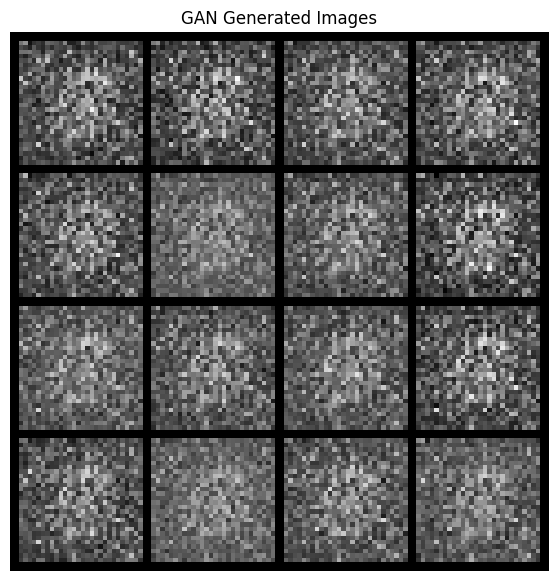

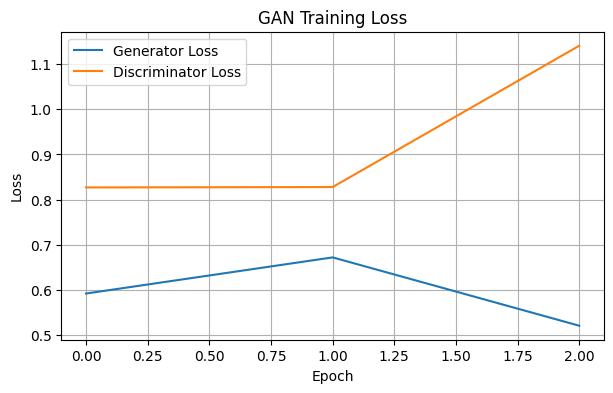

GAN image generation completed successfully.


In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((28,28)),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataset = Subset(dataset, range(1000))
loader = DataLoader(dataset, batch_size=64, shuffle=True)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100,128),
            nn.ReLU(),
            nn.Linear(128,256),
            nn.ReLU(),
            nn.Linear(256,784),
            nn.Tanh()
        )

    def forward(self,z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784,256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,128),
            nn.LeakyReLU(0.2),
            nn.Linear(128,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
g_optimizer = torch.optim.Adam(G.parameters(),lr=0.0002)
d_optimizer = torch.optim.Adam(D.parameters(),lr=0.0002)

g_losses = []
d_losses = []

for epoch in range(3):
    for real,_ in loader:
        real = real.view(-1,784).to(device)
        batch_size = real.size(0)

        real_labels = torch.ones(batch_size,1).to(device)
        fake_labels = torch.zeros(batch_size,1).to(device)

        z = torch.randn(batch_size,100).to(device)
        fake = G(z)

        d_real = D(real)
        d_fake = D(fake.detach())

        d_loss = criterion(d_real,real_labels) + criterion(d_fake,fake_labels)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        z = torch.randn(batch_size,100).to(device)
        fake = G(z)

        g_loss = criterion(D(fake),real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(f"Epoch {epoch+1}/3 | Generator Loss: {g_loss.item():.4f} | Discriminator Loss: {d_loss.item():.4f}")

G.eval()

with torch.no_grad():
    z = torch.randn(16,100).to(device)
    generated = G(z).view(-1,1,28,28).cpu()

grid = torchvision.utils.make_grid(
    generated,
    nrow=4,
    normalize=True
)

plt.figure(figsize=(7,7))
plt.imshow(grid.permute(1,2,0),cmap="gray")
plt.axis("off")
plt.title("GAN Generated Images")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(g_losses,label="Generator Loss")
plt.plot(d_losses,label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

print("GAN image generation completed successfully.")